
===== BoW Vectorization =====

5-Fold Cross-Validation Averages:
Accuracy : 0.9785
Precision: 0.9914
Recall   : 0.9671
F1-score : 0.9791
ROC AUC  : 0.9960
Total Training Time for 5 Folds: 0.42 seconds

Test Set Results:
Accuracy : 0.9773
Precision: 0.9904
Recall   : 0.9657
F1-score : 0.9779
ROC AUC  : 0.9960
Training Time on Full Training Set: 0.07 seconds
Confusion Matrix:
 [[7839   80]
 [ 294 8285]]


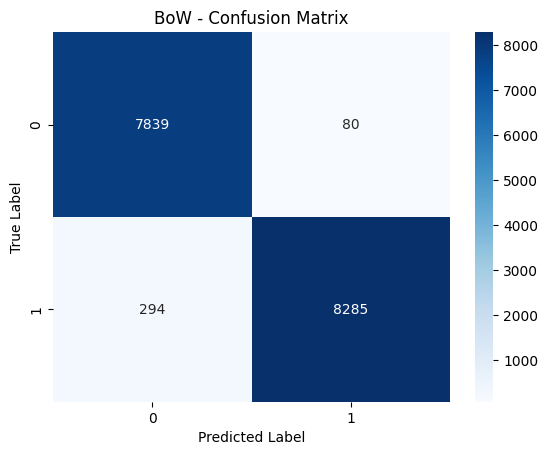

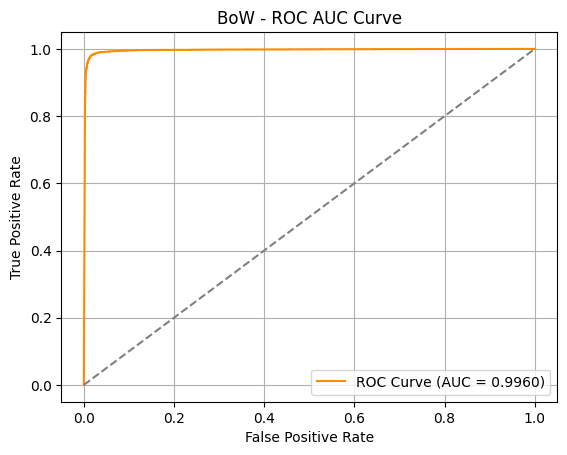


===== TF-IDF Vectorization =====

5-Fold Cross-Validation Averages:
Accuracy : 0.9767
Precision: 0.9893
Recall   : 0.9656
F1-score : 0.9773
ROC AUC  : 0.9980
Total Training Time for 5 Folds: 0.47 seconds

Test Set Results:
Accuracy : 0.9763
Precision: 0.9891
Recall   : 0.9650
F1-score : 0.9769
ROC AUC  : 0.9980
Training Time on Full Training Set: 0.08 seconds
Confusion Matrix:
 [[7828   91]
 [ 300 8279]]


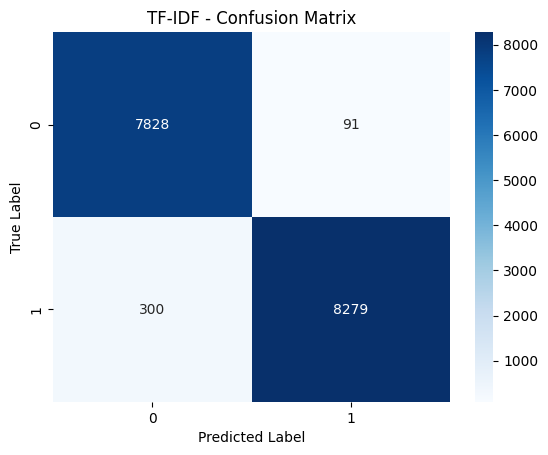

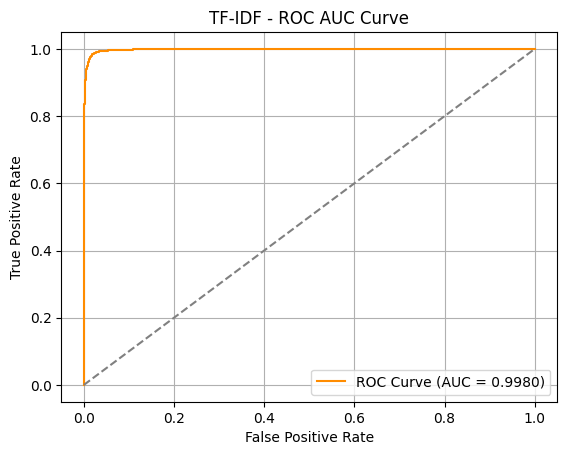

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)

# ====== Step 1: Load and split data ======
df = pd.read_csv('phishing_email.csv')
X = df['text_combined']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# ====== Step 2: Define vectorizers ======
vectorizers = {
    'BoW': CountVectorizer(stop_words='english', max_df=0.7),
    'TF-IDF': TfidfVectorizer(stop_words='english', max_df=0.7)
}

# ====== Step 3: Loop over vectorizers ======
for name, vectorizer in vectorizers.items():
    print(f"\n===== {name} Vectorization =====")

    accuracy_list = []
    precision_list = []
    recall_list = []
    f1_list = []
    roc_auc_list = []
    fold_times = []

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        X_train_vec = vectorizer.fit_transform(X_train_fold)
        X_val_vec = vectorizer.transform(X_val_fold)

        model = MultinomialNB()

        start_time = time.time()
        model.fit(X_train_vec, y_train_fold)

        y_pred = model.predict(X_val_vec)
        y_proba = model.predict_proba(X_val_vec)[:, 1]

        train_time = time.time() - start_time
        fold_times.append(train_time)

        accuracy_list.append(accuracy_score(y_val_fold, y_pred))
        precision_list.append(precision_score(y_val_fold, y_pred))
        recall_list.append(recall_score(y_val_fold, y_pred))
        f1_list.append(f1_score(y_val_fold, y_pred))

        fpr, tpr, _ = roc_curve(y_val_fold, y_proba)
        roc_auc_list.append(auc(fpr, tpr))

    # ====== Step 4: Print average 5-fold result ======
    print("\n5-Fold Cross-Validation Averages:")
    print(f"Accuracy : {np.mean(accuracy_list):.4f}")
    print(f"Precision: {np.mean(precision_list):.4f}")
    print(f"Recall   : {np.mean(recall_list):.4f}")
    print(f"F1-score : {np.mean(f1_list):.4f}")
    print(f"ROC AUC  : {np.mean(roc_auc_list):.4f}")
    print(f"Total Training Time for 5 Folds: {np.sum(fold_times):.2f} seconds")

    # ====== Step 5: Retrain on full train set and test on test set ======
    X_train_vec_full = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    model = MultinomialNB()

    start_time = time.time()
    model.fit(X_train_vec_full, y_train)
    test_train_time = time.time() - start_time

    y_test_pred = model.predict(X_test_vec)
    y_test_proba = model.predict_proba(X_test_vec)[:, 1]

    acc = accuracy_score(y_test, y_test_pred)
    pre = precision_score(y_test, y_test_pred)
    rec = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    cm = confusion_matrix(y_test, y_test_pred)
    fpr, tpr, _ = roc_curve(y_test, y_test_proba)
    roc_auc = auc(fpr, tpr)

    # ====== Step 6: Print test results ======
    print("\nTest Set Results:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {pre:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC AUC  : {roc_auc:.4f}")
    print(f"Training Time on Full Training Set: {test_train_time:.2f} seconds")
    print("Confusion Matrix:\n", cm)

    # ====== Step 7: Plot confusion matrix ======
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'{name} - Confusion Matrix')
    plt.show()

    # ====== Step 8: Plot ROC curve ======
    plt.figure()
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})', color='darkorange')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{name} - ROC AUC Curve')
    plt.legend()
    plt.grid(True)
    plt.show()
